# XGBM & LGBM

### Exploratory Data Analysis (EDA)

In [109]:
# Importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [7]:
# Loading Dataset
titanic_train=pd.read_csv('C:/Data Science/Assignments_Files/XGBM & LGBM/Titanic_train.csv')
titanic_test=pd.read_csv('C:/Data Science/Assignments_Files/XGBM & LGBM/Titanic_test.csv')

In [27]:
# Taking Preview
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
# Taking Preview
titanic_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [13]:
# Understanding dataset information
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
# Checking rows and columns
titanic_train.shape

(891, 12)

In [17]:
# Understanding Statistical Information
titanic_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [33]:
# We have to drop columns from both test and train data for model compatibility
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']

titanic_train = titanic_train.drop(drop_cols, axis=1)
titanic_test = titanic_test.drop(drop_cols, axis=1)

In [19]:
# Checking for duplicates
titanic_train.duplicated().sum()

np.int64(0)

In [37]:
# Checking for Missing Values
titanic_train.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [23]:
# Filling null values of Age with median
titanic_train['Age'].fillna(titanic_train['Age'].median(), inplace=True)

In [47]:
# We drop the 2 Null values from Embarked
titanic_train.dropna(subset=['Embarked'],inplace=True)

In [49]:
# Checking final for Null Values
titanic_train.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

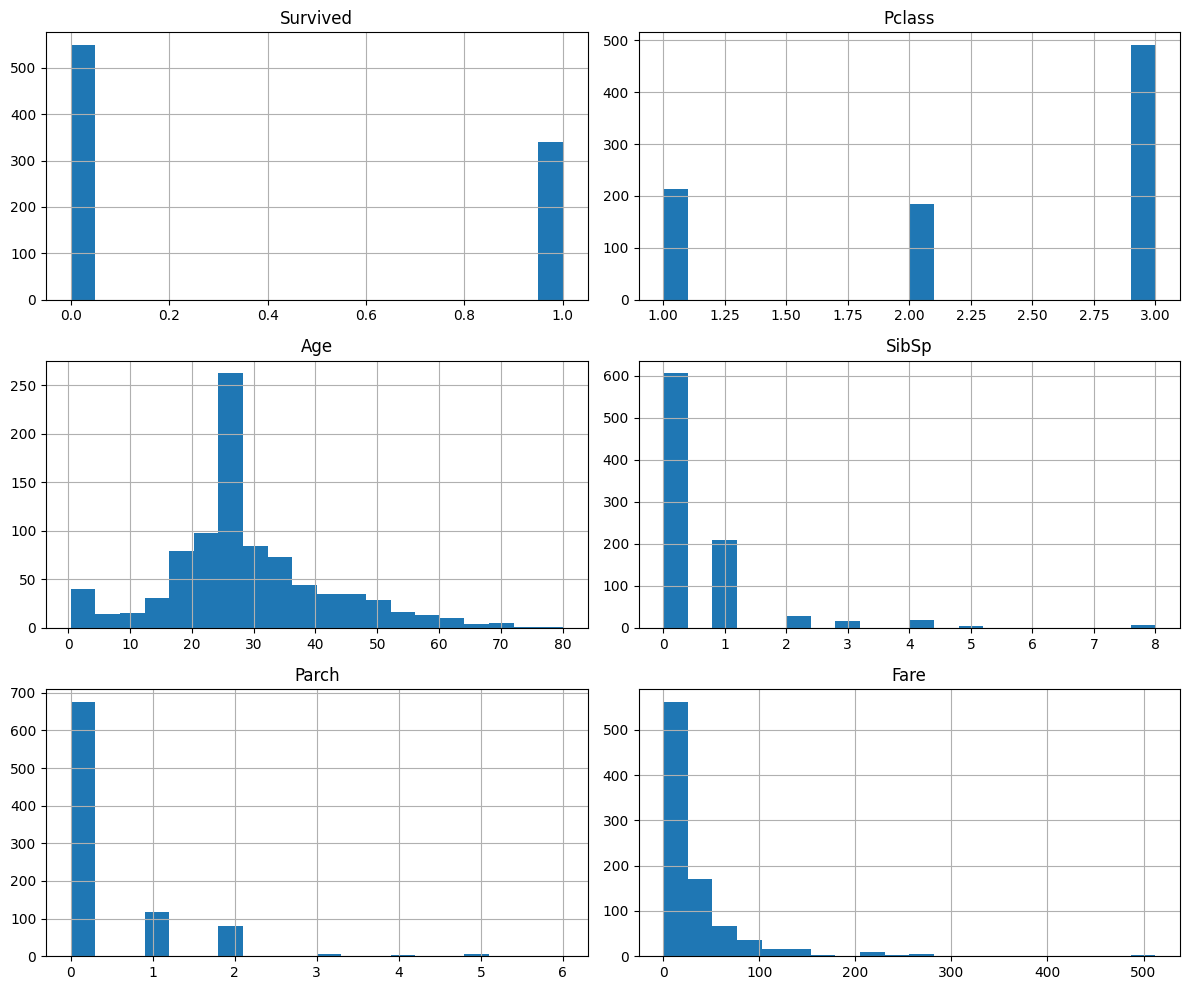

In [55]:
# Data Visualization
# Histograms for Data Distribution
titanic_train.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

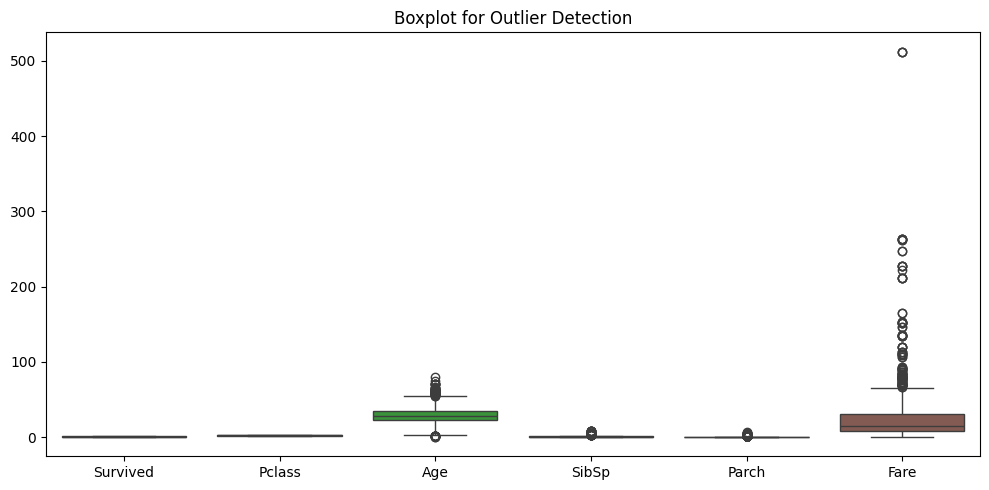

In [65]:
# Boxplot for Outlier Detection
plt.figure(figsize=(10,5))
sns.boxplot(data=titanic_train)
plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()

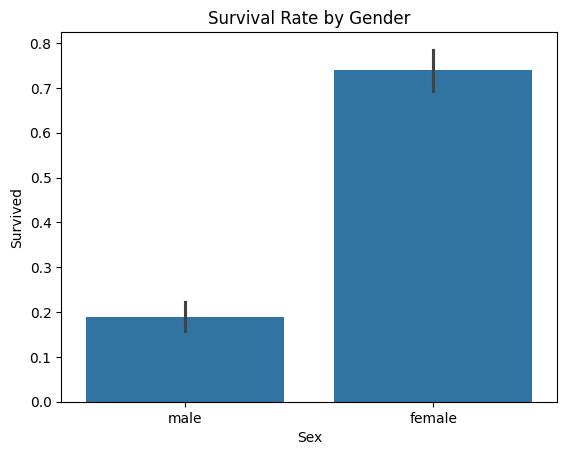

In [67]:
# Checking for Survival vs Features
# 1. Gender vs Survival
sns.barplot(x='Sex', y='Survived', data=titanic_train)
plt.title("Survival Rate by Gender")
plt.show()

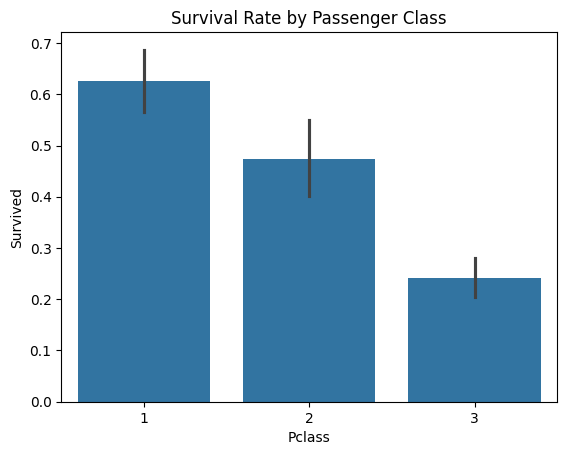

In [69]:
# 2. Class vs Survival
sns.barplot(x='Pclass', y='Survived', data=titanic_train)
plt.title("Survival Rate by Passenger Class")
plt.show()

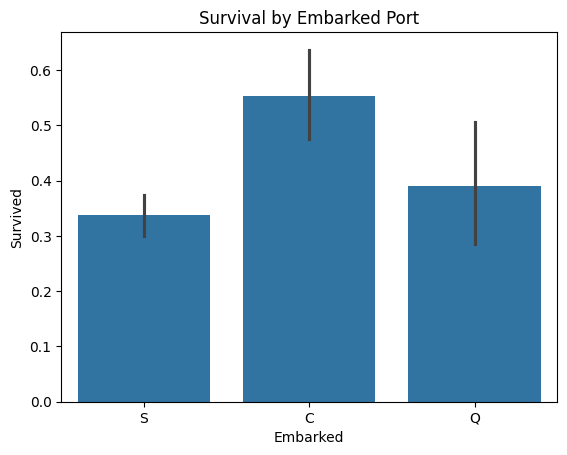

In [73]:
# 3. Embarked vs Survival
sns.barplot(x='Embarked', y='Survived', data=titanic_train)
plt.title("Survival by Embarked Port")
plt.show()

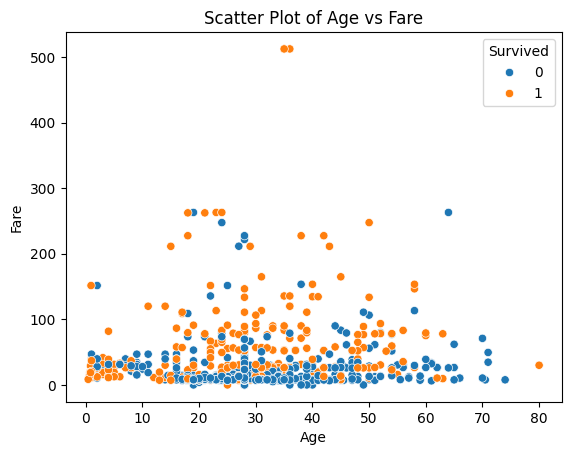

In [75]:
# Scatter Plots
# Age vs Fare
sns.scatterplot(x='Age',y='Fare',hue='Survived',data=titanic_train)
plt.title("Scatter Plot of Age vs Fare")
plt.show()

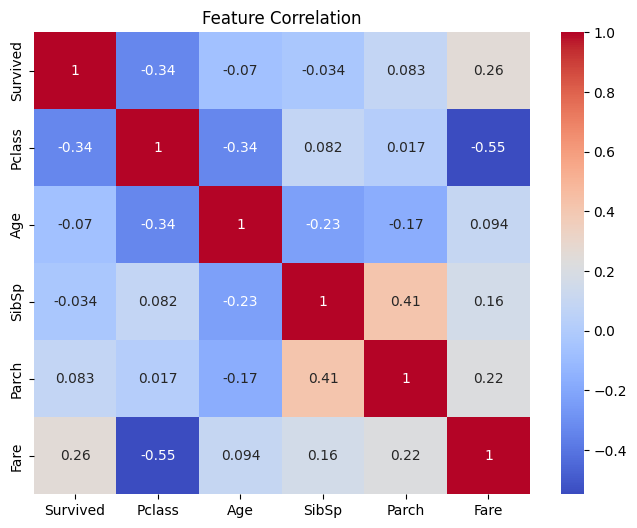

In [77]:
# Correlation Matrix
corr = titanic_train.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

### Data Preprocessing

In [82]:
# Encode Categorical Variables
# Convert Sex (Label Encoding)
titanic_train['Sex'] = titanic_train['Sex'].map({'male': 0, 'female': 1})
titanic_test['Sex'] = titanic_test['Sex'].map({'male': 0, 'female': 1})

In [84]:
# One-Hot Encoding for Embarked
titanic_train = pd.get_dummies(titanic_train, columns=['Embarked'], drop_first=True)
titanic_test = pd.get_dummies(titanic_test, columns=['Embarked'], drop_first=True)

In [88]:
# Ensuring Same Columns in Train & Test
titanic_train, titanic_test = titanic_train.align(titanic_test, join='left', axis=1, fill_value=0)

### Building Predictive Models

In [95]:
# Train-Test Split
X = titanic_train.drop('Survived', axis=1)
y = titanic_train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [97]:
# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [101]:
# Training LightGBM Model
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 271, number of negative: 440
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 201
[LightGBM] [Info] Number of data points in the train set: 711, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381153 -> initscore=-0.484656
[LightGBM] [Info] Start training from score -0.484656
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [105]:
# Training XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [107]:
# Evaluate Both Models on Testing data
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name} Performance:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

evaluate_model(y_test, lgb_pred, "LightGBM")
evaluate_model(y_test, xgb_pred, "XGBoost")


LightGBM Performance:
Accuracy: 0.8089887640449438
Precision: 0.7611940298507462
Recall: 0.7391304347826086
F1 Score: 0.75

XGBoost Performance:
Accuracy: 0.7921348314606742
Precision: 0.7162162162162162
Recall: 0.7681159420289855
F1 Score: 0.7412587412587412


In [111]:
# Cross-Validation 
lgb_cv = cross_val_score(lgb_model, X, y, cv=5, scoring='accuracy')
xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

print("LightGBM CV Accuracy:", lgb_cv.mean())
print("XGBoost CV Accuracy:", xgb_cv.mean())

[LightGBM] [Info] Number of positive: 272, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 202
[LightGBM] [Info] Number of data points in the train set: 711, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.382560 -> initscore=-0.478697
[LightGBM] [Info] Start training from score -0.478697
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [113]:
# Hyperparameter Tuning
# LightGBM
lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [115]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

### Comparative Analysis

In [120]:
# Creating Comparison Table
results = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lgb_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, lgb_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, lgb_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lgb_pred),
        f1_score(y_test, xgb_pred)
    ]
})

print(results)

      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.808989   0.761194  0.739130  0.750000
1   XGBoost  0.792135   0.716216  0.768116  0.741259


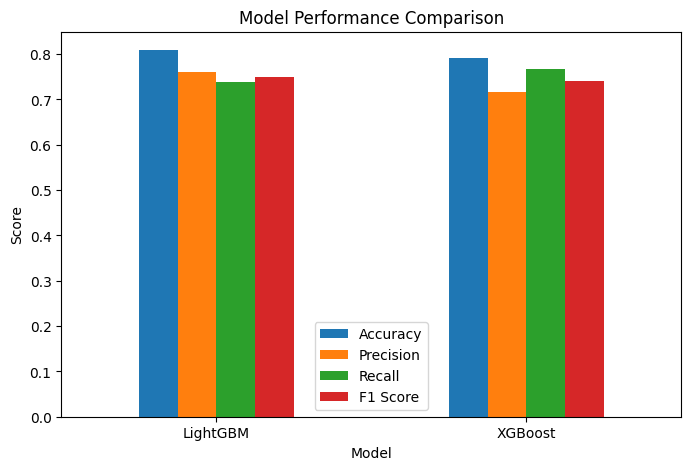

In [122]:
# Visualization
# Bar Plot Comparison
results.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Comparative Analysis of Models

The performance of LightGBM and XGBoost was evaluated using accuracy, precision, recall, and F1-score.

- **LightGBM** achieved higher **accuracy (0.809)** and **precision (0.761)** compared to XGBoost. This means LightGBM made more correct predictions overall and had fewer false positives.

- **XGBoost** showed higher **recall (0.768)**, indicating it was better at identifying actual survivors, even if it made slightly more false positive errors.

- The **F1-score** of both models is very close, with LightGBM slightly higher (0.750 vs 0.741), showing balanced performance.

### Conclusion:
Overall, **LightGBM performs slightly better** due to higher accuracy and F1-score. However, **XGBoost is better when recall is important**, meaning it is more effective at capturing actual positive cases.